# Image Recognition with MNIST Dataset

This notebook builds and trains a Convolutional Neural Network (CNN) on the MNIST dataset for digit recognition (0-9).

## What is MNIST?
- Modified National Institute of Standards and Technology database
- 70,000 images of handwritten digits (0-9)
- Each image: 28x28 pixels, grayscale (single channel)
- 60,000 training images, 10,000 test images
- Standard benchmark for image classification

## Concepts covered
- Loading and preprocessing image data
- Building CNN architecture
- Training and evaluating neural networks
- Visualizing predictions

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I0000 00:00:1781184071.407080   22119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781184084.171714   22119 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781184095.822160   22119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Building the CNN model for MNIST
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model Architecture:")
model.summary()

I0000 00:00:1781184103.113107   22119 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Load MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train_full.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training labels shape: {y_train_full.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Pixel value range: {X_train_full.min()} to {X_train_full.max()}")
print(f"Unique digits in training set: {np.unique(y_train_full)}")

# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape to add channel dimension (for grayscale images)
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"\nAfter preprocessing:")
print(f"Training data shape: {X_train_full.shape}")
print(f"Test data shape: {X_test.shape}")

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)
Pixel value range: 0 to 255
Unique digits in training set: [0 1 2 3 4 5 6 7 8 9]

After preprocessing:
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)

Train set shape: (48000, 28, 28, 1)
Validation set shape: (12000, 28, 28, 1)


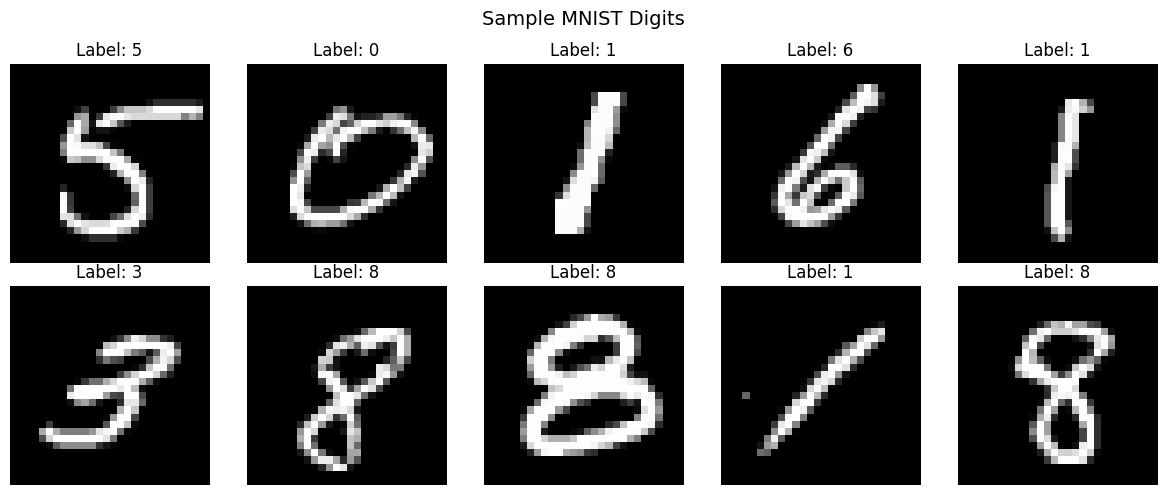

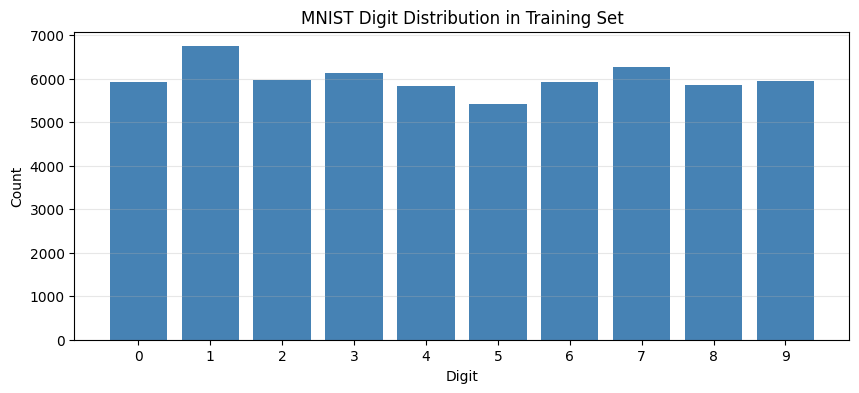

In [4]:
# Visualize sample images from MNIST
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Label: {y_train[i]}')
    axes[i].axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=14)
plt.tight_layout()
plt.show()

# Check class distribution
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(unique, counts, color='steelblue')
plt.title('MNIST Digit Distribution in Training Set')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

X_train shape: (48000, 28, 28, 1)
y_train shape: (48000,)
X_val shape: (12000, 28, 28, 1)
y_val shape: (12000,)
Epoch 1/15


I0000 00:00:1781184111.326606   23286 service.cc:153] XLA service 0x7f684c005360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781184111.326762   23286 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1781184111.404538   23286 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781184111.688070   23286 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1781184111.727971   23286 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1945__.32


  2/375 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.0977 - loss: 2.2979   

I0000 00:00:1781184121.900913   23286 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.8854 - loss: 0.3674 - val_accuracy: 0.9728 - val_loss: 0.0879
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9691 - loss: 0.1038 - val_accuracy: 0.9822 - val_loss: 0.0558
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9784 - loss: 0.0744 - val_accuracy: 0.9852 - val_loss: 0.0496
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9828 - loss: 0.0586 - val_accuracy: 0.9873 - val_loss: 0.0442
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9860 - loss: 0.0460 - val_accuracy: 0.9887 - val_loss: 0.0370
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9881 - loss: 0.0401 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9903 - loss: 0.0329 - val_accuracy: 0.9887 - val_loss: 0.0433
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9902 - loss: 0.0308 - val_accuracy: 0.9894

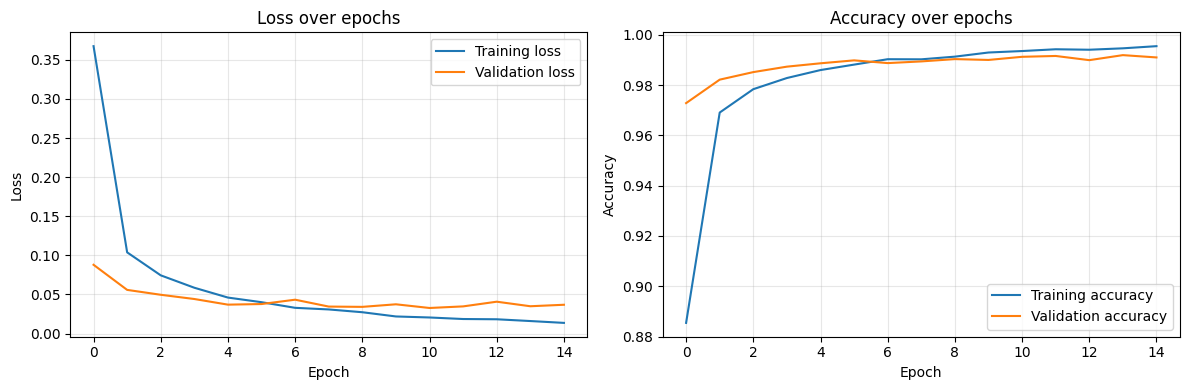

In [5]:
# Training the model
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Test Loss: 0.0289
Test Accuracy: 0.9928


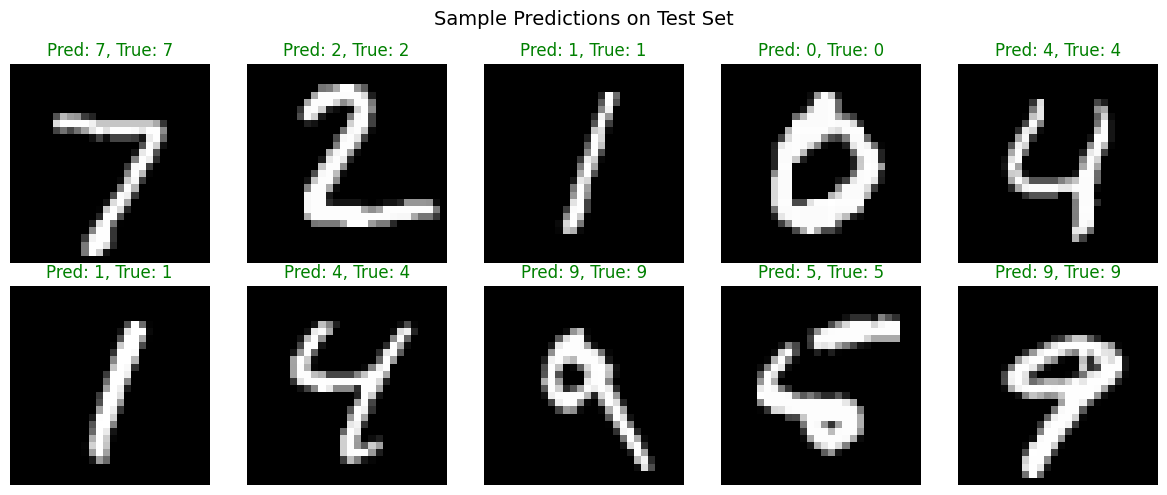

In [6]:
# Model evaluation on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred, axis=1)

# Show some predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    pred_label = y_pred_labels[i]
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {pred_label}, True: {true_label}', color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Model deployment and evaluation summary
model.save('mnist_digit_recognition_model.keras')
print("Model saved as 'mnist_digit_recognition_model.keras'")

print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)
print(f"Test Set Performance:")
print(f"  - Accuracy: {test_accuracy*100:.2f}%")
print(f"  - Loss: {test_loss:.4f}")
print(f"\nTotal Parameters: {model.count_params():,}")
print("="*50)

Model saved as 'mnist_digit_recognition_model.keras'

FINAL MODEL EVALUATION
Test Set Performance:
  - Accuracy: 99.28%
  - Loss: 0.0289

Total Parameters: 130,890
